# Figure 8: Forced Response and Delayed Warming in EPT

In [1]:
import os
import cartopy
import cartopy.crs as ccrs
import cmcrameri.cm as cmc
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xcdat as xc
import xskillscore as xscore

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from typing import Tuple

# Plotting Utils

In [90]:
def _global_plot(
    ax, 
    data, 
    lon, 
    lat, 
    cmap="RdBu_r", 
    pvalues=None, 
    right_title="", 
    left_title="", 
    levels=np.arange(-4, 4.1, .1), 
    cbar_label: str = "",
    colors=None,
):
    if colors is None: 
        img = ax.contourf(
            lon, lat, data,
            transform=ccrs.PlateCarree(),
            # colors=cmap, # uncomment for reds
            cmap=cmap,
            extend="both",
            levels=levels,
        )
    else: 
        cmap = matplotlib.cm.get_cmap(cmap)
        norm = matplotlib.colors.Normalize(vmin=np.min(levels), vmax=np.max(levels))
        cmap = [cmap(norm(l)) for l in levels]
        cmap[0] = (1, 1, 1, 1) # Set first element to white

        img = ax.contourf(
            lon, lat, data,
            transform=ccrs.PlateCarree(),
            colors=cmap, # uncomment for reds
            extend="max",
            levels=levels,
        )

    # Add Stippling
    if pvalues is not None:
        ax.contourf(
            lon, lat, pvalues,
            colors='none',
            levels=[0, .05, 1],
            hatches=['...', None,],
            transform=ccrs.PlateCarree(), 
        )
    
        
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False

    ax.add_feature(cartopy.feature.LAND, facecolor="gray", edgecolor="black", zorder=3)

    # Draw triangular region
    lat_min, lat_max = -38.75, -1.25
    lon_min, lon_max = -178.75, -71.25
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min], 
        [lat_max, lat_max, lat_min, lat_max], 
        color="black", linewidth=2, transform=ccrs.PlateCarree(), zorder=10
    )

    # # Southern Ocean
    # bound_region(ax, lons=(-180, -75), lats=(-70, -50), color="black")

    ax.coastlines()
    ax.set_global()
    ax.set_title(left_title, loc="left", fontweight="bold")
    ax.set_title(right_title, loc="right")
    lon_min, lon_max = -180, 180
    lat_min, lat_max = -90, 30
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # add cbar label to top of colorbar
    # cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=.030, pad=0.02)
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=.020, pad=0.02)
    cbar.ax.set_title(cbar_label, fontsize=10)

    return img

def bound_region(ax, lons, lats, color):
    lon_min, lon_max = lons
    lat_min, lat_max = lats

    # Draw a black bounding box around region
    ax.plot(
        [lon_min, lon_min, lon_max, lon_max, lon_min], 
        [lat_min, lat_max, lat_max, lat_min, lat_min], 
        color=color, linewidth=2, transform=ccrs.PlateCarree(), zorder=10
    )

In [58]:
def plot_global_map_grid(
    plot_configs,
    save_path=None,
    ncols=2,
    figsize=(15, 10),
    hspace=0.25,
    wspace=0.1,
):
    """
    Plots an n×n grid of global maps using plot configs.

    Args:
        plot_configs (list of dict): Each dict should include:
            - 'data': 2D array to plot
            - 'lat': latitude array
            - 'lon': longitude array
            - 'title': title string (right-aligned)
            - 'label': subplot label (e.g. "A", "B") (left-aligned)
            - 'levels': contour levels
            - 'cmap': colormap name
            - 'pvalues': 2D array for stippling (optional)
        save_path (str): Base path (without extension) to save PNG and PDF
        ncols (int): Number of columns in the grid
        figsize (tuple): Overall figure size
        cbar_label (str): Label for the colorbar
        hspace (float): Vertical spacing between plots
        wspace (float): Horizontal spacing between plots
        suptitle (str): Optional figure-wide title
    """
    from math import ceil

    nplots = len(plot_configs)
    nrows = ceil(nplots / ncols)

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(nrows, ncols, hspace=hspace, wspace=wspace)

    axes = []

    for i, cfg in enumerate(plot_configs):
        row = i // ncols
        col = i % ncols
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree(central_longitude=180))
        axes.append(ax)

        # Plot
        img = _global_plot(
            ax=ax,
            data=cfg['data'],
            lat=cfg['lat'],
            lon=cfg['lon'],
            cmap=cfg.get('cmap', 'Reds'),
            levels=cfg.get('levels', np.linspace(0, 0.5, 11)),
            pvalues=cfg.get('pvalues', None),
            cbar_label=cfg.get('cmap_label', ""),
            colors=cfg.get('colors', None)
        )

        # Titles
        ax.set_title(cfg.get('title', ""), loc="right", fontsize=14)
        ax.set_title(cfg.get('label', ""), loc="left", fontweight="bold", fontsize=16)

    if save_path:
        plt.savefig(save_path + ".png", dpi=300, bbox_inches="tight")
        plt.savefig(save_path + ".pdf", dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}.png/.pdf")

    plt.show()

In [63]:
def plot_model_maps_with_shared_colorbar(
    data,                          # xarray DataArray with dims (model, lat, lon)
    cmap='RdBu_r',
    levels=np.arange(-1.5, 1.6, 0.1),
    cbar_label='K/K',
    ncols=5,
    figsize_per_plot=(4, 3),
    central_longitude=180,
    save_path=None,
    labels=None,

):
    n_models = data.sizes['model']
    nrows = int(np.ceil(n_models / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(figsize_per_plot[0] * ncols,
                                      figsize_per_plot[1] * nrows),
                             subplot_kw={'projection': ccrs.PlateCarree(central_longitude=central_longitude)},
                             gridspec_kw={'hspace': -0.5, 'wspace': 0.05}
                            )
    
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < n_models:
            model_data = data.isel(model=i)
            cf = ax.contourf(model_data.lon, model_data.lat, model_data,
                             levels=levels, cmap=cmap, extend='both',
                             transform=ccrs.PlateCarree())
            ax.coastlines()
            ax.set_title(str(model_data.model.values), loc="left")
            ax.set_title(np.around(labels.isel(model=i).values, 2), loc="right")
            lon_min, lon_max = -180, 180
            lat_min, lat_max = -90, 30
            ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

            ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                        linewidth=2, color='gray', alpha=0.5, linestyle='--')

            ax.add_feature(cartopy.feature.LAND, facecolor="gray", edgecolor="black", zorder=3)

            # Show lat ticks on the left column
            if i % ncols == 0:
                ax.set_yticks(np.arange(-90, 31, 30), crs=ccrs.PlateCarree())
                ax.tick_params(labelleft=True)
            else:
                ax.set_yticks([])

            # Show lon ticks on the bottom row
            if i // ncols == nrows - 1:
                ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
                ax.tick_params(labelbottom=True)
            else:
                ax.set_xticks([])
        else:
            ax.axis('off')

    # Shared colorbar
    cbar = fig.colorbar(cf, ax=axes[:n_models], orientation='horizontal', pad=0.04, shrink=0.7)
    cbar.set_label(cbar_label)
    fig.tight_layout()
   
    if save_path is not None: 
        plt.savefig(save_path + ".png", dpi=300, bbox_inches="tight")
        plt.savefig(save_path + ".pdf", dpi=300, bbox_inches="tight")

In [88]:
def get_shared_models(ds1: xr.Dataset, ds2: xr.Dataset) -> Tuple[xr.Dataset, xr.Dataset]:
    shared_models = list(set(ds1.model.values).intersection(set(ds2.model.values)))
    return ds1.sel(model=shared_models), ds2.sel(model=shared_models)

def fix_coords(data):
    data = data.bounds.add_bounds("X")
    data = data.bounds.add_bounds("Y")
    data = data.bounds.add_bounds("T")
    data = xc.swap_lon_axis(data, to=(-180, 180))
    return data

def fix_coords_no_time(data):
    data = data.bounds.add_bounds("X")
    data = data.bounds.add_bounds("Y")
    data = xc.swap_lon_axis(data, to=(-180, 180))
    return data

def fix_coords_no_space(data):
    data = data.bounds.add_bounds("T")
    return data

def get_triangle(tos, latmin: float = -38.75, latmax: float = -1.25, lonmin: float = -178.75, lonmax: float = -71.25, RES: float = 2.5):
    DY = latmax - latmin
    DX = lonmax - lonmin 
    dx = RES*round(DX/DY)
    dy = RES

    print(f"For each latitude step of {dy} degrees, longitude step is {dx}")

    latcoords = np.arange(latmax, latmin-dy, -dy)
    loncoords = np.arange(lonmin, lonmax+dx, dx)
    lonraw = np.arange(lonmin, lonmax+dx, RES)

    ctos = tos.sel(lon=slice(lonmin, lonmax), lat=slice(latmin, latmax))
    nmodel, ntime, _, nlon = ctos.shape

    for i, clon in enumerate(lonraw):
        j = np.where(clon == loncoords)[0]

        if i == nlon: break

        if len(j) == 0: 
            j = jold
        else: 
            j = j[0]
             
        nlats = int(len(latcoords) - j) # nlats below diag
        ctos[:,:,:nlats,i] = np.full((nmodel, ntime, nlats), np.nan) 
        
        jold = j
    
    return ctos

def get_triangle_notime(tos, latmin: float = -38.75, latmax: float = -1.25, lonmin: float = -178.75, lonmax: float = -71.25, RES: float = 2.5):
    DY = latmax - latmin
    DX = lonmax - lonmin 
    dx = RES*round(DX/DY)
    dy = RES

    print(f"For each latitude step of {dy} degrees, longitude step is {dx}")

    latcoords = np.arange(latmax, latmin-dy, -dy)
    loncoords = np.arange(lonmin, lonmax+dx, dx)
    lonraw = np.arange(lonmin, lonmax+dx, RES)

    ctos = tos.sel(lon=slice(lonmin, lonmax), lat=slice(latmin, latmax))
    nmodel, _, nlon = ctos.shape

    for i, clon in enumerate(lonraw):
        j = np.where(clon == loncoords)[0]

        if i == nlon: break

        if len(j) == 0: 
            j = jold
        else: 
            j = j[0]
             
        nlats = int(len(latcoords) - j) # nlats below diag
        ctos[:,:nlats,i] = np.full((nmodel, nlats), np.nan) 
        
        jold = j
    
    return ctos





# Load Data

In [68]:
DATA_ROOT = "/home/espinosa10/SO-EP-teleconnection/Data"

# 4xCO2
sst_cmip6_4xc02 = xr.open_dataset("/home/espinosa10/tropical_pacific_clouds/data/4xCO2/tos_mon_150yrs_CMIP6_4xCO2.nc")
sst_cmip5_4xc02 = xr.open_dataset("/home/espinosa10/tropical_pacific_clouds/data/4xCO2/tos_mon_150yrs_CMIP5_4xCO2.nc") 
sst_cmip5_4xc02 = sst_cmip5_4xc02.where(sst_cmip5_4xc02 != 0) - 273.15
sst_cmip_4xc02 = fix_coords(xr.concat([sst_cmip6_4xc02, sst_cmip5_4xc02], dim="model"))
sst_cmip_4xc02 = sst_cmip_4xc02.drop_sel(model=["MIROC5", "FGOALS-s2", "GFDL-ESM2G-1", "GISS-E2-R", "E3SM-2-0-NARRM", "CMCC-CM2-HR4", "IPSL-CM6A-LR-INCA"])

cmip_4xc02_ept_sst = fix_coords(get_triangle(sst_cmip_4xc02.tos.copy(deep=True)).to_dataset()).spatial.average("tos")
cmip_4xc02_so_sst = sst_cmip_4xc02.sel(lon=slice(-180, -75), lat=slice(-70, -50)).spatial.average("tos")
cmip_4xc02_global_sst = sst_cmip_4xc02.spatial.average("tos")

# dEPT/dSO at variance timescales: CMIP
rvalues_so_ept_coupling = xr.open_dataset(os.path.join(DATA_ROOT, "so_ept_coupling.nc"))
# SWCF EPSA
swcf_cmip6_epsa = xr.open_dataarray("/home/espinosa10/tropical_pacific_clouds/data/piControl/swcf_east_sa_cmip6_v3.nc") 
swcf_cmip5_epsa = xr.open_dataarray("/home/espinosa10/tropical_pacific_clouds/data/piControl/swcf_east_sa_cmip5_v3.nc") 
swcf_cmip_epsa = xr.concat([swcf_cmip6_epsa, swcf_cmip5_epsa], dim="model")
# Southern ITCZ from CMIP
cmip_precip_south_east_clim = xr.open_dataset(os.path.join(DATA_ROOT, "cmip_pr_south_east_clim.nc"))["pr"]

For each latitude step of 2.5 degrees, longitude step is 7.5


In [ ]:
# # Drop models: "MIROC5"
# cmip6_clim = sst_cmip_4xc02.isel(time=0)
# for model in cmip6_clim.model.values:
#     plt.figure() # Create a new figure for each plot
#     cmip6_clim.sel(model=model)["tos"].plot()
#     plt.title(f'wap700 Climatology for Model: {model}') # Optional: Add a title
# plt.show() # Display all figures

In [46]:
# Walker Circulation 
psl_cmip6_4xc02 = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/psl_mon_CMIP6_4xC02.nc")
psl_cmip5_4xc02 = xr.open_dataset("/home/espinosa10/SO-EP-teleconnection/Data/psl_mon_CMIP5_4xC02.nc")
psl_cmip_4xc02 = fix_coords(xr.concat([psl_cmip6_4xc02, psl_cmip5_4xc02], dim="model"))

# Calculate Walker Circulation
west = psl_cmip_4xc02.sel(lat=slice(-5, 5), lon=slice(130, 150)).spatial.average("psl")["psl"]
east = psl_cmip_4xc02.sel(lat=slice(-5, 5), lon=slice(-180, -80)).spatial.average("psl")["psl"]
walker = fix_coords_no_space((east - west).to_dataset(name="walker"))
# Fix times
walker["time"] = sst_cmip_4xc02.time

# W-E SST Gradient
west = fix_coords(sst_cmip_4xc02["tos"].to_dataset()).sel(lat=slice(-5, 5), lon=slice(110, 150)).spatial.average("tos")["tos"]
east = fix_coords(sst_cmip_4xc02["tos"].to_dataset()).sel(lat=slice(-5, 5), lon=slice(-180, -80)).spatial.average("tos")["tos"]
WE_sst = fix_coords_no_space((west - east).to_dataset(name="WE_sst"))

In [47]:
# early_slice = slice(0, 12*10)
# late_slice = slice(12*10, 12*150)
early_slice = slice(0, 12*19)
late_slice = slice(12*20, 12*150)
sst_cmip_4xc02_early = sst_cmip_4xc02.isel(time=early_slice)["tos"].resample(time="1Y").mean("time")
sst_cmip_4xc02_late = sst_cmip_4xc02.isel(time=late_slice)["tos"].resample(time="1Y").mean("time")
sst_cmip_4xc02_late = sst_cmip_4xc02.isel(time=late_slice)["tos"].resample(time="1Y").mean("time")

global_cmip_4xc02_early = cmip_4xc02_global_sst.isel(time=early_slice)["tos"].resample(time="1Y").mean("time")
global_cmip_4xc02_late = cmip_4xc02_global_sst.isel(time=late_slice)["tos"].resample(time="1Y").mean("time")

# Group by models with high and low coupling
so_ept_coupling_5year = rvalues_so_ept_coupling.reg.sel(years=12*5)
so_ept_coupling_5year, sst_cmip_4xc02 = get_shared_models(so_ept_coupling_5year, sst_cmip_4xc02)

global_cmip_4xc02_late = global_cmip_4xc02_late.sel(model=sst_cmip_4xc02.model)
global_cmip_4xc02_early = global_cmip_4xc02_early.sel(model=sst_cmip_4xc02.model)

bottom_half_coupling = so_ept_coupling_5year[so_ept_coupling_5year < so_ept_coupling_5year.median()]
top_half_coupling = so_ept_coupling_5year[so_ept_coupling_5year >= so_ept_coupling_5year.median()]

# SO 
so = sst_cmip_4xc02.sel(lon=slice(-180, -75), lat=slice(-70, -50)).mean(["lat", "lon"])

# Early All
early_model = xscore.linslope(global_cmip_4xc02_early, sst_cmip_4xc02_early, dim="time")
early = early_model.mean("model")
# Early Low Coupling
early_low = sst_cmip_4xc02_early.sel(model=bottom_half_coupling.model)
early_low = xscore.linslope(global_cmip_4xc02_early.sel(model=bottom_half_coupling.model), early_low, dim="time").mean("model")
# Early High Coupling
early_high = sst_cmip_4xc02_early.sel(model=top_half_coupling.model)
early_high = xscore.linslope(global_cmip_4xc02_early.sel(model=top_half_coupling.model), early_high, dim="time").mean("model")
# Late All
late_model = xscore.linslope(global_cmip_4xc02_late, sst_cmip_4xc02_late, dim="time")
late = late_model.mean("model")
# Late Low Coupling
late_low = sst_cmip_4xc02_late.sel(model=bottom_half_coupling.model)
late_low = xscore.linslope(global_cmip_4xc02_late.sel(model=bottom_half_coupling.model), late_low, dim="time").mean("model")
# Late High Coupling
late_high = sst_cmip_4xc02_late.sel(model=top_half_coupling.model)
late_high = xscore.linslope(global_cmip_4xc02_late.sel(model=top_half_coupling.model), late_high, dim="time").mean("model")

In [48]:
# Save model list strong and weak coupling
# top_half_coupling["model"].to_netcdf("/home/espinosa10/SO-EP-teleconnection/Data/cmip_top_quantile_strong_so-ept_coupling.nc")
# bottom_half_coupling["model"].to_netcdf("/home/espinosa10/SO-EP-teleconnection/Data/cmip_bottom_quantile_weak_so-ept_coupling.nc")

W-E Equatorial Pacific SST Gradient

In [49]:
WE_sst_cmip_4xc02_early = WE_sst.isel(time=early_slice)["WE_sst"].resample(time="1Y").mean("time")
WE_sst_cmip_4xc02_late = WE_sst.isel(time=late_slice)["WE_sst"].resample(time="1Y").mean("time")

_, bottom_half_WE_sst = get_shared_models(WE_sst_cmip_4xc02_early, bottom_half_coupling)
_, top_half_WE_sst = get_shared_models(WE_sst_cmip_4xc02_early, top_half_coupling)

WE_sst_cmip_4xc02_early_low = WE_sst_cmip_4xc02_early.sel(model=bottom_half_WE_sst.model).mean("model")
WE_sst_cmip_4xc02_early_high = WE_sst_cmip_4xc02_early.sel(model=top_half_WE_sst.model).mean("model")

WE_sst_cmip_4xc02_late_low = WE_sst_cmip_4xc02_late.sel(model=bottom_half_WE_sst.model).mean("model")
WE_sst_cmip_4xc02_late_high =WE_sst_cmip_4xc02_late.sel(model=top_half_WE_sst.model).mean("model")

# Walker Circulation: Early Low coupling
WE_sst_early_low = xscore.linslope(global_cmip_4xc02_early.sel(model=bottom_half_WE_sst.model), WE_sst_cmip_4xc02_early_low, dim="time") #.mean("model")
WE_sst_early_high = xscore.linslope(global_cmip_4xc02_early.sel(model=top_half_WE_sst.model), WE_sst_cmip_4xc02_early_high, dim="time") #.mean("model")

WE_sst_late_low = xscore.linslope(global_cmip_4xc02_late.sel(model=bottom_half_WE_sst.model), WE_sst_cmip_4xc02_late_low, dim="time") #.mean("model")
WE_sst_late_high = xscore.linslope(global_cmip_4xc02_late.sel(model=top_half_WE_sst.model), WE_sst_cmip_4xc02_late_high, dim="time")#.mean("model")

Walker Circulation

In [50]:
walker_cmip_4xc02_early = walker.isel(time=early_slice)["walker"].resample(time="1Y").mean("time")
walker_cmip_4xc02_late = walker.isel(time=late_slice)["walker"].resample(time="1Y").mean("time")

_, bottom_half_walker = get_shared_models(walker_cmip_4xc02_early, bottom_half_coupling)
_, top_half_walker = get_shared_models(walker_cmip_4xc02_early, top_half_coupling)

walker_cmip_4xc02_early_low = walker_cmip_4xc02_early.sel(model=bottom_half_walker.model).mean("model")
walker_cmip_4xc02_early_high = walker_cmip_4xc02_early.sel(model=top_half_walker.model).mean("model")

walker_cmip_4xc02_late_low = walker_cmip_4xc02_late.sel(model=bottom_half_walker.model).mean("model")
walker_cmip_4xc02_late_high = walker_cmip_4xc02_late.sel(model=top_half_walker.model).mean("model")

# Walker Circulation: Early Low coupling
walker_early_low = xscore.linslope(global_cmip_4xc02_early.sel(model=bottom_half_walker.model), walker_cmip_4xc02_early_low, dim="time") #.mean("model")
walker_early_high = xscore.linslope(global_cmip_4xc02_early.sel(model=top_half_walker.model), walker_cmip_4xc02_early_high, dim="time") #.mean("model")

walker_late_low = xscore.linslope(global_cmip_4xc02_late.sel(model=bottom_half_walker.model), walker_cmip_4xc02_late_low, dim="time") #.mean("model")
walker_late_high = xscore.linslope(global_cmip_4xc02_late.sel(model=top_half_walker.model), walker_cmip_4xc02_late_high, dim="time")#.mean("model")

# Figure 8: Revisions Updated (2 x 2)
Showing Late, Early, Late - Early, Correlation

/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:351: RuntimeWarning: invalid value encountered in divide
  t_squared = r ** 2 * (dof / ((1.0 - r) * (1.0 + r)))
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:352: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/tmp/ipykernel_4016550/421122225.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.ge

Saved to Figure_7_revised.png/.pdf


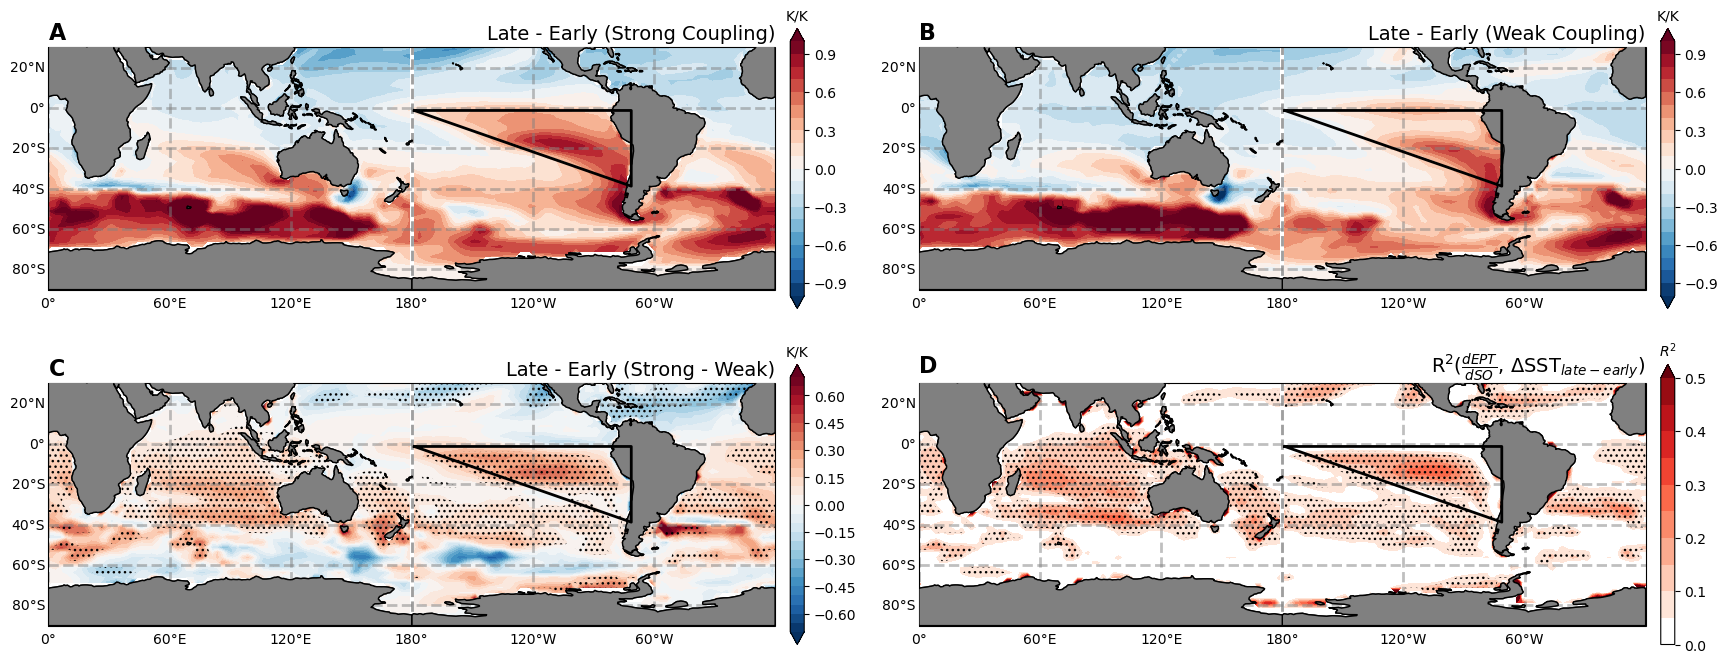

In [91]:
sst_late_minus_early = late_model - early_model
so_ept_coupling_5year, sst_late_minus_early = get_shared_models(so_ept_coupling_5year, sst_late_minus_early)
r_late_early_maps = xscore.pearson_r(so_ept_coupling_5year, sst_late_minus_early, skipna=True, dim="model")
p_late_early_maps = xscore.pearson_r_p_value(so_ept_coupling_5year, sst_late_minus_early, skipna=True,dim="model")

plot_configs = [
    {
        "data": (late_high - early_high).values,
        "lat": early_low.lat,
        "lon": early_low.lon,
        "levels": np.arange(-1, 1.1, 0.1),
        "cmap": "RdBu_r",
        "cmap_label": "K/K",
        "title": r"Late - Early (Strong Coupling)",
        "label": "A"
    },
    {
        "data": (late_low - early_low).values,
        "lat": early_low.lat,
        "lon": early_low.lon,
        "levels": np.arange(-1, 1.1, 0.1),
        "cmap": "RdBu_r",
        "cmap_label": "K/K",
        "title": r"Late - Early (Weak Coupling)",
        "label": "B"
    },
    {
        "data": ((late_high - late_low) - (early_high - early_low)).values,
        "lat": early_low.lat,
        "lon": early_low.lon,
        "levels": np.arange(-.70, .75, 0.05),
        "pvalues": p_late_early_maps.values,
        "cmap": "RdBu_r",
        "cmap_label": "K/K",
        "title": r"Late - Early (Strong - Weak)", 
        "label": "C"
    },
    {
        "data": r_late_early_maps**2,
        "lat": early_low.lat,
        "lon": early_low.lon,
        "pvalues": p_late_early_maps.values,
        "levels": np.arange(0, 0.55, 0.05),
        "cmap": "Reds",
        "colors": "Reds",
        "cmap_label": r"$R^2$",
        "title": r"R$^2$($\frac{dEPT}{dSO}$, $\Delta$SST$_{late - early}$)",
        "label": "D"
    },
]

plot_global_map_grid(
    plot_configs,
    save_path="Figure_7_revised",
    ncols=2,
    figsize=(21, 8),
    hspace=0.20,
    wspace=0.15,
)

# Figure SX - 7 Old

/tmp/ipykernel_3751737/2024109204.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


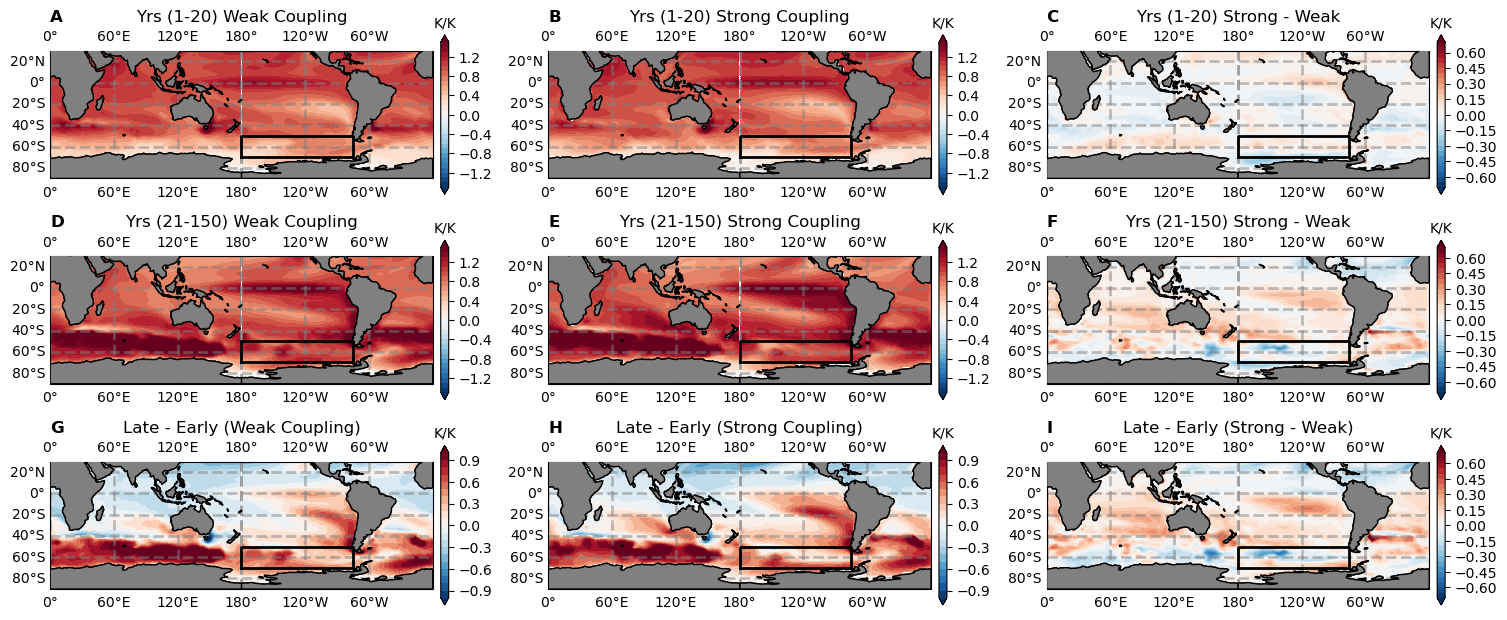

In [25]:
# Create a figure and define a GridSpec with three rows and three columns
# fig = plt.figure(figsize=(18, 10))
fig = plt.figure(figsize=(18, 8))
# gs = GridSpec(3, 3, wspace=0.25, hspace=0.30)
gs = GridSpec(3, 3, wspace=0.25, hspace=0.00)

# Define the levels and colormap for the plots
levels = np.arange(-2, 2.1, 0.1)
diff_levels = np.arange(-1, 1.1, 0.1)
col3_levels = np.arange(-.70, .75, 0.05)
warming_levels = np.arange(-1.5, 1.6, 0.1)
cmap = "RdBu_r"

# Plot early_low
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax1, data=early_low.values, lat=early_low.lat, lon=early_low.lon, levels=warming_levels, cmap=cmap, cbar_label="K/K")
ax1.set_title(r"Yrs (1-20) Weak Coupling")
ax1.set_title("A", loc="left", fontweight="bold")

# Plot early_high
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax2, data=early_high.values, lat=early_high.lat, lon=early_high.lon, levels=warming_levels, cmap=cmap, cbar_label="K/K")
ax2.set_title(r"Yrs (1-20) Strong Coupling")
ax2.set_title("B", loc="left", fontweight="bold")

# Plot difference between early_high and early_low
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax3, data = (early_high - early_low).values, lat=early_low.lat, lon=early_low.lon, levels=col3_levels, cmap=cmap, cbar_label="K/K")
ax3.set_title(r"Yrs (1-20) Strong - Weak")
ax3.set_title("C", loc="left", fontweight="bold")

# Plot late_low
ax4 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax4, data=late_low.values, lat=late_low.lat, lon=late_low.lon, levels=warming_levels, cmap=cmap, cbar_label="K/K")
ax4.set_title(r"Yrs (21-150) Weak Coupling")
ax4.set_title("D", loc="left", fontweight="bold")

# Plot late_high
ax5 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax5, data=late_high.values, lat=late_high.lat, lon=late_high.lon, levels=warming_levels, cmap=cmap, cbar_label="K/K")
ax5.set_title(r"Yrs (21-150) Strong Coupling")
ax5.set_title("E", loc="left", fontweight="bold")

# Plot difference between late_high and late_low
ax6 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax6, data=(late_high - late_low).values, lat=late_low.lat, lon=late_low.lon, levels=col3_levels, cmap=cmap, cbar_label="K/K")
ax6.set_title(r"Yrs (21-150) Strong - Weak")
ax6.set_title("F", loc="left", fontweight="bold")

# Plot difference between early_low and late_low
ax7 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax7, data=(late_low - early_low).values, lat=early_low.lat, lon=early_low.lon, levels=diff_levels, cmap=cmap, cbar_label="K/K")
ax7.set_title(r"Late - Early (Weak Coupling)")
ax7.set_title("G", loc="left", fontweight="bold")

# Plot difference between early_high and late_high
ax8 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax8, data=(late_high - early_high).values, lat=early_high.lat, lon=early_high.lon, levels=diff_levels, cmap=cmap, cbar_label="K/K")
ax8.set_title(r"Late - Early (Strong Coupling)")
ax8.set_title("H", loc="left", fontweight="bold")

# Plot difference between (early_high - early_low) and (late_high - late_low)
ax9 = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax9, data=((late_high - late_low) - (early_high - early_low)).values, lat=early_low.lat, lon=early_low.lon, levels=col3_levels, cmap=cmap, cbar_label="K/K")
ax9.set_title(r"Late - Early (Strong - Weak)")
ax9.set_title("I", loc="left", fontweight="bold")

#########################################################################
plt.tight_layout()
plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/Main/Figure_7_v2.png", dpi=300, bbox_inches="tight")
plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/Main/Figure_7_v2.pdf", dpi=300, bbox_inches="tight")

# Figure SX: Correlate SO warming with global maps
This takes the average warming in SO K/K late - early and correlates it with point-wise late - old. 
This will tells us if in general, SO delayed warming correlates with other points delayed warming. 

/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:351: RuntimeWarning: invalid value encountered in divide
  t_squared = r ** 2 * (dof / ((1.0 - r) * (1.0 + r)))
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:352: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)
/tmp/ipykernel_2929941/3014568961.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.g

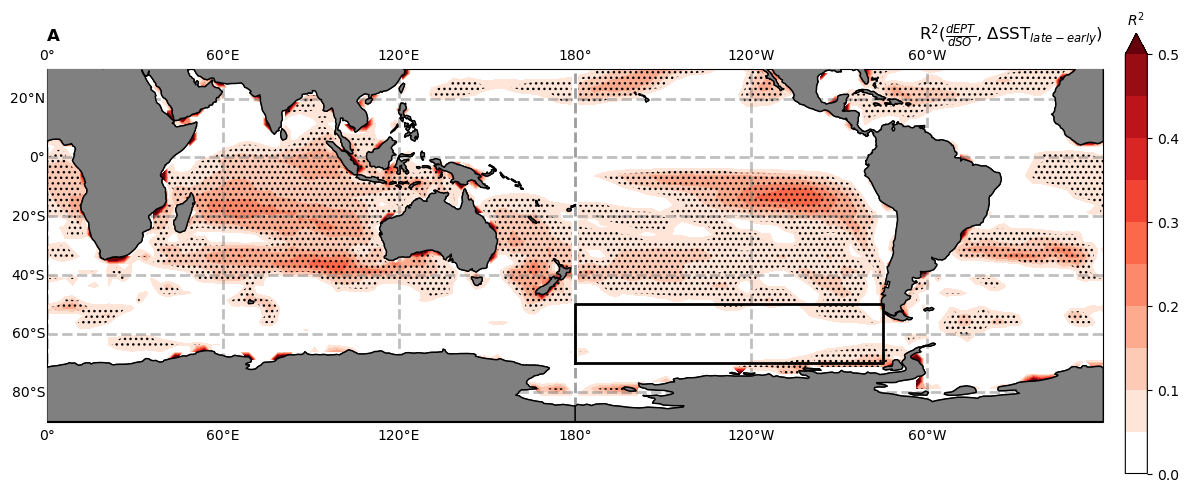

In [53]:
sst_late_minus_early = late_model - early_model
so_ept_coupling_5year, sst_late_minus_early = get_shared_models(so_ept_coupling_5year, sst_late_minus_early)
r_late_early_maps = xscore.pearson_r(so_ept_coupling_5year, sst_late_minus_early, skipna=True, dim="model")
p_late_early_maps = xscore.pearson_r_p_value(so_ept_coupling_5year, sst_late_minus_early, skipna=True,dim="model")

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(1, 1)


ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))

# Define the levels and colormap for the plots
levels=np.arange(0, 0.55, 0.05)
cmap = "Reds"

# Draw triangular region
# lat_min, lat_max = -40, 0
# lon_min, lon_max = -180, -70
# ax1.plot(
#     [lon_min, lon_max, lon_max, lon_min], 
#     [lat_max, lat_max, lat_min, lat_max], 
#     color="black", linewidth=2, transform=ccrs.PlateCarree(), zorder=10
# )
_global_plot(ax1, data=r_late_early_maps**2, lat=early_low.lat, lon=early_low.lon, levels=levels, colors=cmap, cmap=cmap, cbar_label=r"$R^2$", pvalues=p_late_early_maps.values)
ax1.set_title(r"R$^2$($\frac{dEPT}{dSO}$, $\Delta$SST$_{late - early}$)", loc="right")
ax1.set_title("A", loc="left", fontweight="bold")

plt.tight_layout()
plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/Main/Figure_7_correlations.png", dpi=300, bbox_inches="tight")
plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/Main/Figure_7_correlations.pdf", dpi=300, bbox_inches="tight")

/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:309: RuntimeWarning: invalid value encountered in divide
  r = r_num / r_den
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:351: RuntimeWarning: invalid value encountered in divide
  t_squared = r ** 2 * (dof / ((1.0 - r) * (1.0 + r)))
/home/espinosa10/miniconda3/envs/swc/lib/python3.11/site-packages/xskillscore/core/np_deterministic.py:352: RuntimeWarning: invalid value encountered in divide
  _x = dof / (dof + t_squared)


Text(0.0, 1.0, 'A')

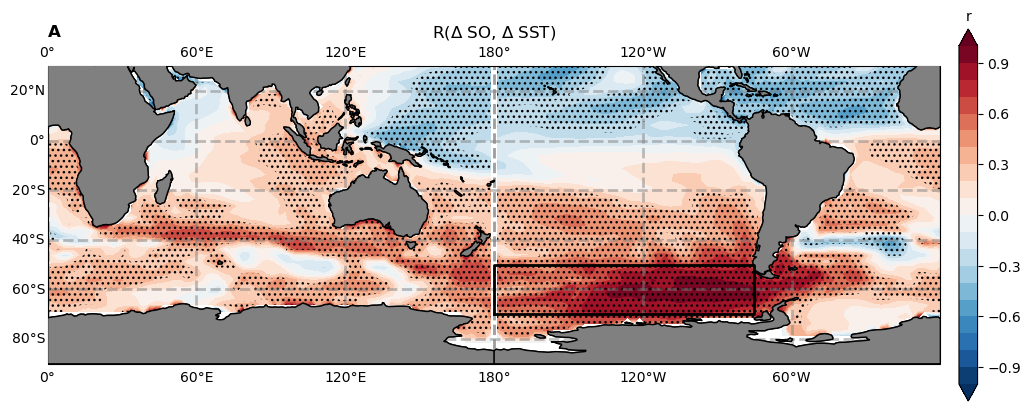

In [ ]:
# sst_late_minus_early = late_model - early_model
# so_late_minus_early = sst_late_minus_early.sel(lon=slice(-180, -75), lat=slice(-70, -50)).mean(["lat", "lon"])

sst_late_minus_early = late_model - early_model
so_late_minus_early = sst_late_minus_early.sel(lon=slice(-180, -75), lat=slice(-70, -50)).mean(["lat", "lon"])

# Regress these together
r_late_early_maps = xscore.pearson_r(so_late_minus_early, sst_late_minus_early, skipna=True,dim="model")
p_late_early_maps = xscore.pearson_r_p_value(so_late_minus_early, sst_late_minus_early, skipna=True,dim="model")

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(1, 1)

# Define the levels and colormap for the plots
levels = np.arange(-1, 1.1, 0.1)
cmap = "RdBu_r"

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax1, data=r_late_early_maps, lat=early_low.lat, lon=early_low.lon, levels=levels, cmap=cmap, cbar_label="r", pvalues=p_late_early_maps.values)
ax1.set_title(r"R($\Delta$ SO, $\Delta$ SST)")
ax1.set_title("A", loc="left", fontweight="bold")

# Figure SX - Plot Each Model sorted by SO-EPT coupling in upper right

/tmp/ipykernel_4016550/2361057002.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


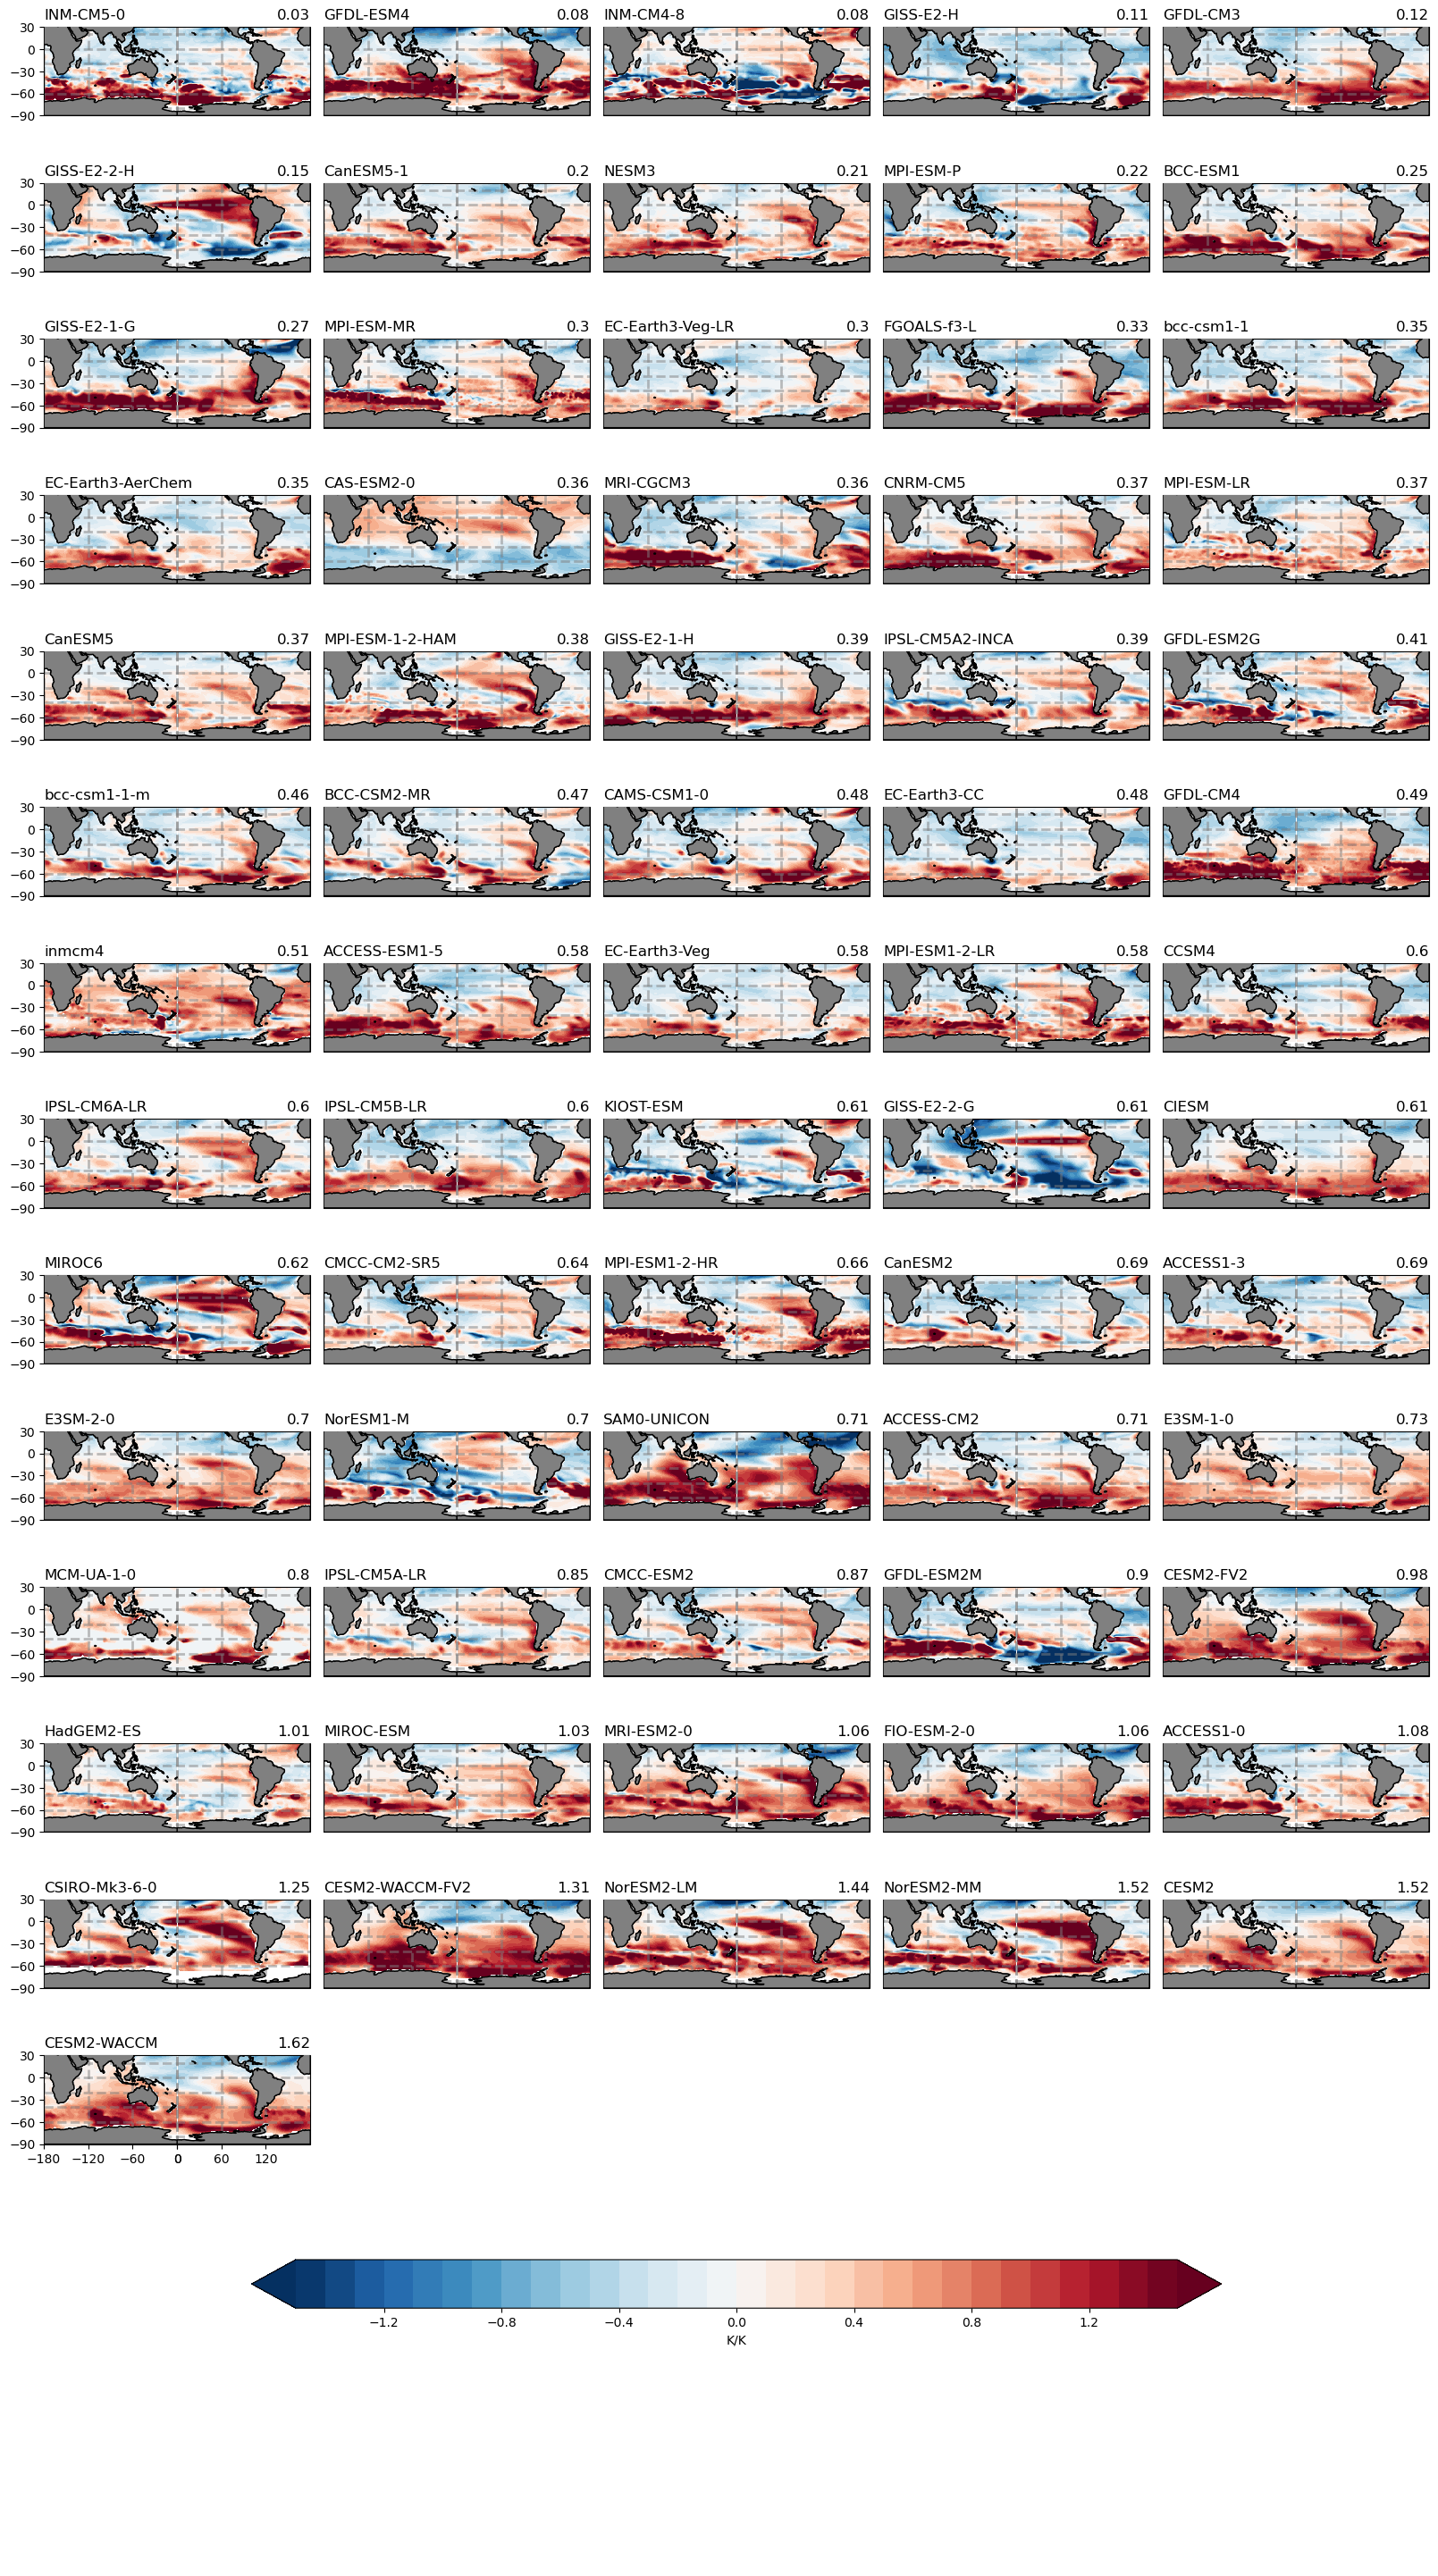

In [64]:
# CMIP5 Models
cmip5_models = sst_cmip5_4xc02.model
_, cmip5_models = get_shared_models(late_model, cmip5_models)
_, cmip5_models = get_shared_models(early_model, cmip5_models)
late_cmip5 = late_model.sel(model=cmip5_models)
early_cmip5 = early_model.sel(model=cmip5_models)
diff_cmip5 = late_cmip5 - early_cmip5
# CMIP6 Models
cmip6_models = sst_cmip6_4xc02.model
_, cmip6_models = get_shared_models(late_model, cmip6_models)
_, cmip6_models = get_shared_models(early_model, cmip6_models)
late_cmip6 = late_model.sel(model=cmip6_models)

early_cmip6 = early_model.sel(model=cmip6_models)
diff_cmip6 = late_cmip6 - early_cmip6
# Combine
late_minus_early_cmip = xr.concat([diff_cmip5, diff_cmip6], dim="model")
# Sort according to SO-EPT coupling
five_yr_coupling, late_minus_early_cmip = get_shared_models(rvalues_so_ept_coupling["reg"].sel(years=12*5), late_minus_early_cmip)
sorted_models = five_yr_coupling.sortby(five_yr_coupling).model
late_minus_early_cmip_sorted = late_minus_early_cmip.sel(model=sorted_models)
five_yr_coupling_sorted = five_yr_coupling.sel(model=sorted_models)

plot_model_maps_with_shared_colorbar(
    late_minus_early_cmip_sorted, 
    labels=five_yr_coupling_sorted,
    save_path="/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/Figure_SX_Late_minus_Early_sorted"
    )

# Dot plots showing
1. Late - Early vs SWCF EPSA
2. Late - Early vs Double ITCZ
3. Late - Early vs SO-EPT Coupling

In [70]:
from scipy.stats import linregress

yr = 12*5
axis_fontsize = 12
title_fontsize = 14

def create_panel_a(ax, x6, y6, x5: list = [], y5: list = [], vline=None) -> None:
    # Set the default color cycle
    colors = ['black','maroon','#7570b3']
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

    CMIP6_label = "CMIP6"
    
    ax.scatter(x6, y6, s=100, alpha=.5, edgecolor="black", color=colors[0], label=CMIP6_label)

    # Multimodel mean
    mmm = np.mean([*x5, *x6])


    x = np.concatenate((x6, x5))
    y = np.concatenate((y6, y5))
    # Sort the lists together based on list1
    x, y  = zip(*sorted(zip(x, y)))

    slope, intercept, r, p, _ = linregress(x,y)
    r, p = np.around(r, 3), np.around(p, 3)
    if p < .05: 
        sig = '*'
    else: 
        sig = ''
    print(r, p)

    x = np.array(sorted(x))
    ax.plot(x, x*slope+intercept, color="black")
    # ax.legend(loc="upper left", fontsize=fontsize)
    ax.set_title(f"r={r}{sig}", loc="right", fontweight="bold", fontsize=title_fontsize)
    
    
    # Define border size - important for emphasizing relationships
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    borderx, bordery = .25*abs(np.max(x)), .25*abs(np.max(y))
    ax.set_xlim(xmin-borderx, xmax+borderx)
    ax.set_ylim(ymin-bordery, ymax+bordery)

    # Vertical line for avg and std of obs
    if vline is None: 
        pass
    else:
        ax.vlines(np.mean(vline), ymin=ymin-bordery, ymax=ymax+bordery, color="orange")
        ax.fill_between(x=[np.mean(vline) - np.std(vline), np.mean(vline) + np.std(vline)], y1=ymin-bordery, y2=ymax+bordery,color="orange", alpha=.25)

    # Add Model Vertical Lines
    ax.vlines(mmm, ymin=ymin-bordery, ymax=ymax+bordery, color=colors[0], label='_nolegend_', alpha=.5, linewidth=2, zorder=0) 
    # ax.fill_between(x=[mmm - np.std(x), mmm + np.std(x)], y1=-1, y2=2.5, color="black", alpha=.25)
    ax.fill_between(x=[mmm - np.std(x), mmm + np.std(x)], y1=np.min(y)*5-100, y2=np.max(y)*5+100, color="black", alpha=.25)

    # Add horizontal sigma lines
    sig_mmm = mmm*slope+intercept
    if vline is not None: sig_obs = np.mean(vline)*slope+intercept
    hline_width = 3
    ax.hlines(y=sig_mmm, xmin=xmin-borderx, xmax=mmm, color="black", linewidth=hline_width)
    if vline is not None: ax.hlines(y=sig_obs, xmin=xmin-borderx, xmax=np.mean(vline), color="orange", linewidth=hline_width)

    ax.text(s=f"{np.around(sig_mmm, 2)}", x=xmin-borderx*.95, y=sig_mmm + sig_mmm*.025, color="black", fontsize=12, fontweight="bold")
    if vline is not None: ax.text(s=f"{np.around(sig_obs, 2)}", x=xmin-borderx*.95, y=sig_obs + sig_mmm*.025, color="orange", fontsize=12, fontweight="bold")

In [97]:
ept_late_early = fix_coords_no_time(
    get_triangle_notime(
        late_minus_early_cmip_sorted.copy(deep=True).drop("years"), 
        latmax=-3.75,
        lonmax=-73.25
        ).to_dataset()
    ).spatial.average("tos").tos

late_minus_early_cmip_swcf, swcf_epsa_dot = get_shared_models(ept_late_early, swcf_cmip_epsa)
late_minus_early_cmip_pr, itcz_dot = get_shared_models(ept_late_early, cmip_precip_south_east_clim)
late_minus_early_cmip_coupling, reg_coupling = get_shared_models(ept_late_early, rvalues_so_ept_coupling.sel(years=12*5)["reg"])
late_minus_early_cmip_coupling

2025-07-25 16:43:48,681 [WARNING]: bounds.py(_create_bounds:398) >> The 'lat' coordinate variable is missing a 'units' attribute. Assuming 'units' is 'degrees_north'.


For each latitude step of 2.5 degrees, longitude step is 7.5


<xarray.DataArray 'tos' (model: 66)>
array([-0.09761802,  0.33598474, -0.32519034,  0.30172244,  0.76828292,
        0.16825946,  0.29759316,  0.15910606,  0.57396225,  0.43917365,
        0.01310882,  0.34063601,  0.34042377,  0.47507171, -0.23620698,
        0.26300253,  1.00868662,  0.66389336,  0.59723003,  0.22678432,
        0.52389969,  0.84459163,  0.78804719, -0.24285474,  0.22997179,
        1.13801388,  0.71553946,  0.01271646,  0.38115098,  0.11484037,
        0.52328841, -0.05717317,  0.29807941,  0.37307826,  0.36178452,
        0.5632116 ,  0.54663383,  0.59436974,  0.21997595,  0.32839468,
        0.21456801, -0.11594708, -0.05810747,  0.15231017,  1.40248112,
        0.56948927,  0.27074014,  0.74291996,  1.11419178,  0.11537972,
        0.47404031, -0.08630248,  0.32178168,  0.28340886,  0.85517419,
       -0.11896917,  0.50164714,  1.01490461,  0.03987363,  1.16278251,
        1.73668999,  0.44917675,  0.09895884,  0.30786081,  0.15993512,
        0.39303191])
Coordinates:
  * model    (model) object 'EC-Earth3-Veg' 'INM-CM4-8' ... 'CanESM5'

0.188 0.154
-0.312 0.013
0.404 0.001


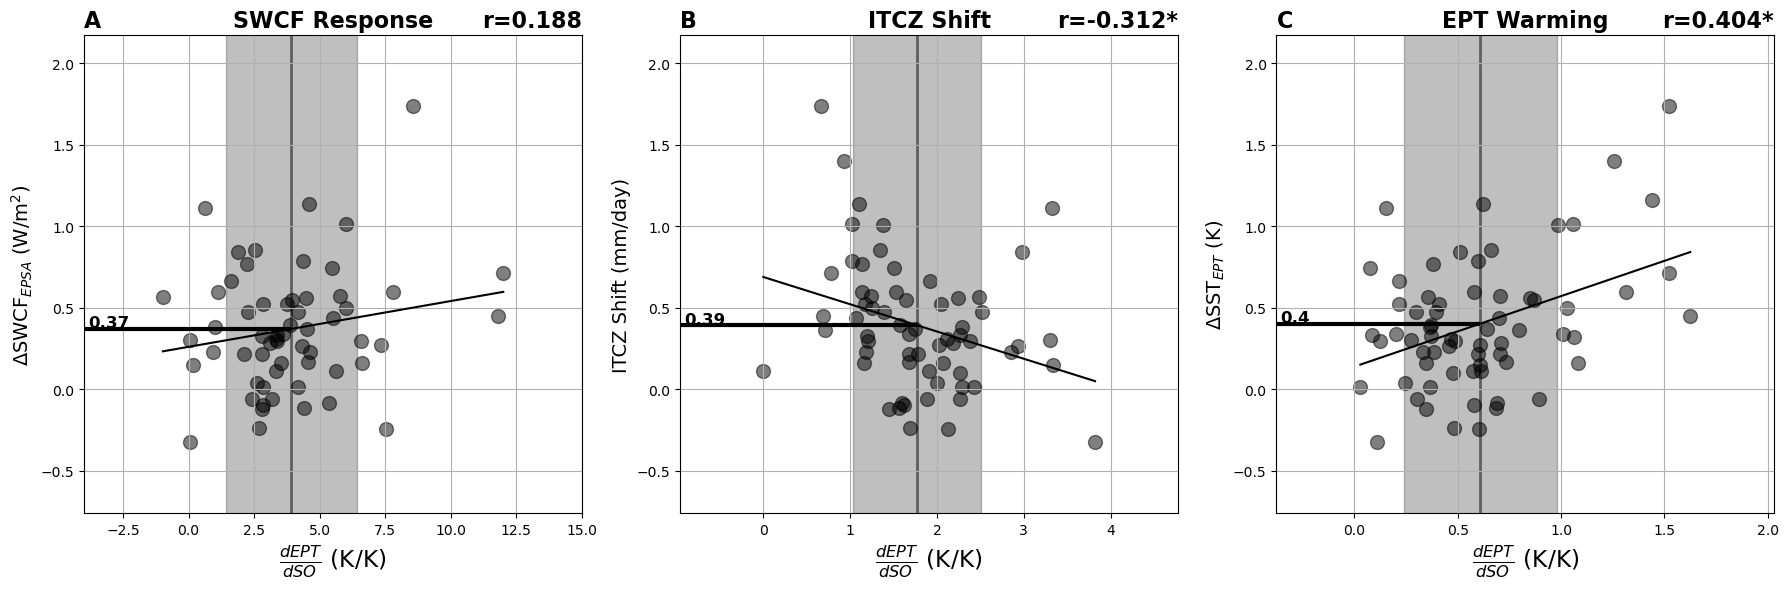

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Axis and title sizes
axis_fontsize = 14
title_fontsize = 16

# Panel A: Late-Early SST vs SWCF
create_panel_a(
    axes[0],
    swcf_epsa_dot,              # y-values
    late_minus_early_cmip_swcf,
    vline=None
)
axes[0].grid()
axes[0].set_ylabel(r"$\Delta$SWCF$_{EPSA}$ (W/m$^2$)", fontsize=axis_fontsize)
axes[0].set_xlabel(r"$\frac{dEPT}{dSO}$ (K/K)", fontsize=axis_fontsize*1.2)
axes[0].set_title("A", loc="left", fontweight="bold", fontsize=title_fontsize)
axes[0].set_title("SWCF Response", fontweight="bold", fontsize=title_fontsize)

# Panel B: Late-Early SST vs ITCZ shift
create_panel_a(
    axes[1],
    itcz_dot,
    late_minus_early_cmip_pr,
    vline=None
)
axes[1].grid()
axes[1].set_ylabel(r"ITCZ Shift (mm/day)", fontsize=axis_fontsize)
axes[1].set_xlabel(r"$\frac{dEPT}{dSO}$ (K/K)", fontsize=axis_fontsize*1.2)
axes[1].set_title("B", loc="left", fontweight="bold", fontsize=title_fontsize)
axes[1].set_title("ITCZ Shift", fontweight="bold", fontsize=title_fontsize)

# Panel C: Late-Early SST vs SO-EPT Coupling
create_panel_a(
    axes[2],
    reg_coupling,
    late_minus_early_cmip_coupling,
    vline=None
)
axes[2].grid()
axes[2].set_ylabel(r"$\Delta$SST$_{EPT}$ (K)", fontsize=axis_fontsize)
axes[2].set_xlabel(r"$\frac{dEPT}{dSO}$ (K/K)", fontsize=axis_fontsize*1.2)
axes[2].set_title("C", loc="left", fontweight="bold", fontsize=title_fontsize)
axes[2].set_title("EPT Warming", fontweight="bold", fontsize=title_fontsize)

plt.tight_layout()

# Figure SX - Plot Early / Late without Grouping at all

Text(0.0, 1.0, 'C')

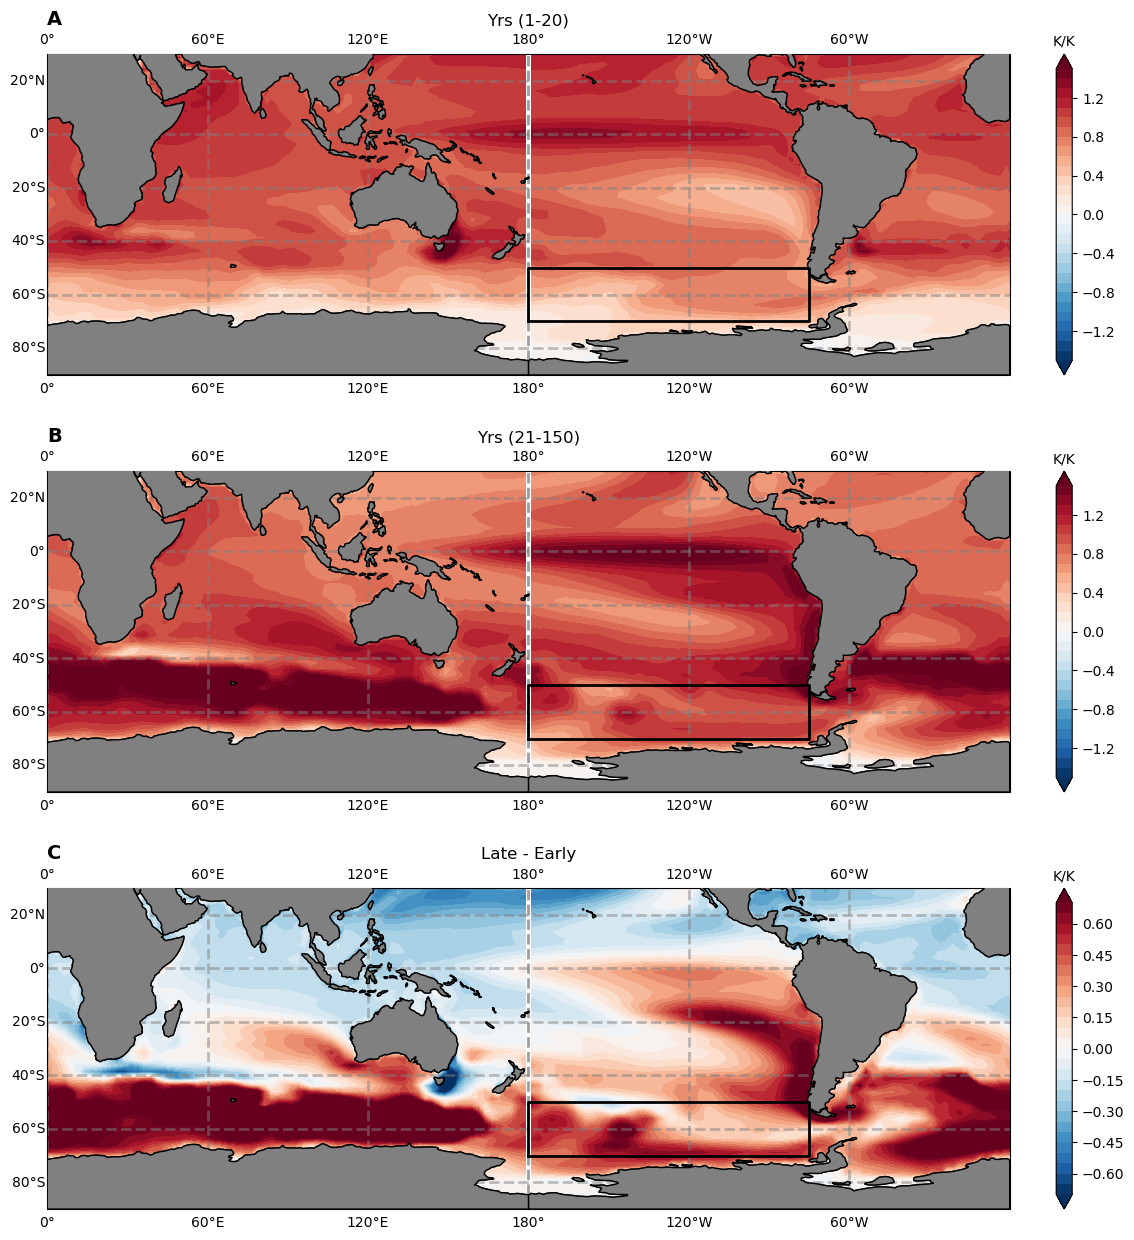

In [23]:
# Create a figure and define a GridSpec with three rows and three columns
fig = plt.figure(figsize=(30, 15))
gs = GridSpec(3, 1, hspace=0.30)

# Define the levels and colormap for the plots
levels = np.arange(-2, 2.1, 0.1)
diff_levels = np.arange(-1, 1.1, 0.1)
col3_levels = np.arange(-.70, .75, 0.05)
warming_levels = np.arange(-1.5, 1.6, 0.1)
cmap = "RdBu_r"

# Plot early
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax1, data=early.values, lat=early.lat, lon=early.lon, levels=warming_levels, cmap=cmap, cbar_label="K/K")
ax1.set_title(r"Yrs (1-20)")
ax1.set_title(r"A", loc="left", fontweight="bold", fontsize=14)

# Plot late
ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax2, data=late.values, lat=late.lat, lon=late.lon, levels=warming_levels, cmap=cmap, cbar_label="K/K")
ax2.set_title(r"Yrs (21-150)")
ax2.set_title(r"B", loc="left", fontweight="bold", fontsize=14)

# Plot difference between early_high and early_low
ax3 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
_global_plot(ax3, data = (late - early).values, lat=late.lat, lon=late.lon, levels=col3_levels, cmap=cmap, cbar_label="K/K")
ax3.set_title(r"Late - Early")
ax3.set_title(r"C", loc="left", fontweight="bold", fontsize=14)

#########################################################################
# plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/Figure_SX_4xWarming.png", dpi=300, bbox_inches="tight")
# plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/Figure_SX_4xWarming.pdf", dpi=300, bbox_inches="tight")

# Figure SX: Walker and WE Response

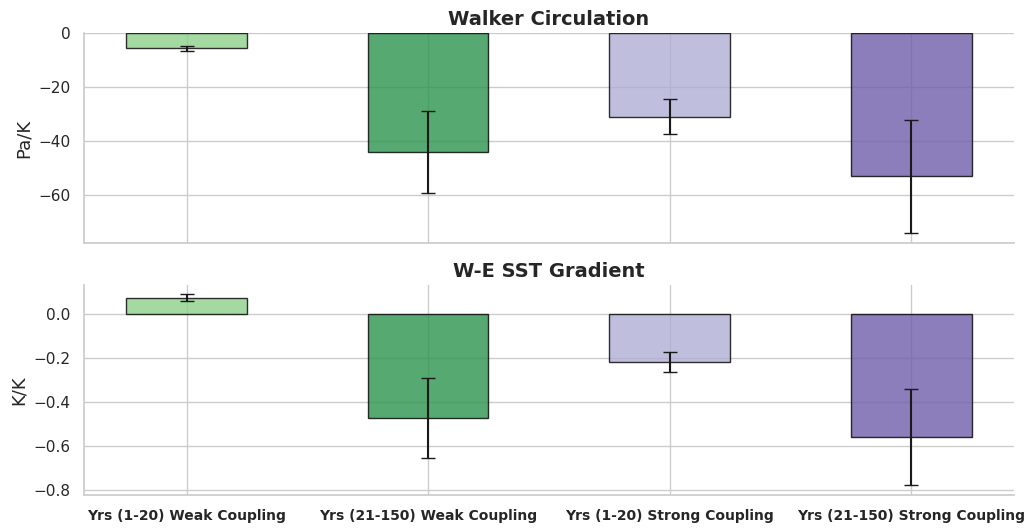

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a modern style
sns.set_theme(style="whitegrid")

# Example data (replace with actual xarray calculations)
bar_width = 0.25
x_positions = [0, 0.5, 1, 1.5]
labels = [
    "Yrs (1-20) Weak Coupling",
    "Yrs (21-150) Weak Coupling",
    "Yrs (1-20) Strong Coupling",
    "Yrs (21-150) Strong Coupling"
]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)  # Two subplots

# === 1st Subplot: Walker Circulation ===
ax1 = axes[0]
ax1.bar(
    x_positions[0], walker_early_low.mean("model"), 
    yerr=walker_early_low.std("model"), width=bar_width, 
    label=labels[0], capsize=5, color=sns.color_palette("Greens")[2], edgecolor="black", alpha=0.8
)
ax1.bar(
    x_positions[1], walker_late_low.mean("model"), 
    yerr=walker_late_low.std("model"), width=bar_width, 
    label=labels[1], capsize=5, color=sns.color_palette("Greens")[4], edgecolor="black", alpha=0.8
)
ax1.bar(
    x_positions[2], walker_early_high.mean("model"), 
    yerr=walker_early_high.std("model"), width=bar_width, 
    label=labels[2], capsize=5, color=sns.color_palette("Purples")[2], edgecolor="black", alpha=0.8
)
ax1.bar(
    x_positions[3], walker_late_high.mean("model"), 
    yerr=walker_late_high.std("model"), width=bar_width, 
    label=labels[3], capsize=5, color=sns.color_palette("Purples")[4], edgecolor="black", alpha=0.8
)

# === 2nd Subplot: W-E SST Gradient ===
ax2 = axes[1]
ax2.bar(
    x_positions[0], WE_sst_early_low.mean("model"), 
    yerr=WE_sst_early_low.std("model"), width=bar_width, 
    label=labels[0], capsize=5, color=sns.color_palette("Greens")[2], edgecolor="black", alpha=0.8
)
ax2.bar(
    x_positions[1], WE_sst_late_low.mean("model"), 
    yerr=WE_sst_late_low.std("model"), width=bar_width, 
    label=labels[1], capsize=5, color=sns.color_palette("Greens")[4], edgecolor="black", alpha=0.8
)
ax2.bar(
    x_positions[2], WE_sst_early_high.mean("model"), 
    yerr=WE_sst_early_high.std("model"), width=bar_width, 
    label=labels[2], capsize=5, color=sns.color_palette("Purples")[2], edgecolor="black", alpha=0.8
)
ax2.bar(
    x_positions[3], WE_sst_late_high.mean("model"), 
    yerr=WE_sst_late_high.std("model"), width=bar_width, 
    label=labels[3], capsize=5, color=sns.color_palette("Purples")[4], edgecolor="black", alpha=0.8
)

ax1.set_title("Walker Circulation", fontsize=14, fontweight="bold")
ax1.set_ylabel(r"Pa/K", fontsize=13)
# ax1.legend(frameon=True, fontsize=11, loc="lower left", bbox_to_anchor=(0, 0))
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.set_title("W-E SST Gradient", fontsize=14, fontweight="bold")
ax2.set_ylabel(r"K/K", fontsize=13)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(labels, rotation=0, ha="center", fontsize=10, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

#########################################################################
# plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/Figure_SX_4xWarming_walker-WE.png", dpi=300, bbox_inches="tight")
# plt.savefig("/home/espinosa10/SO-EP-teleconnection/Manuscript_Figures/SI/Figure_SX_4xWarming_walker-WE.pdf", dpi=300, bbox_inches="tight")